# Previsão de Rotatividade de Funcionários (Attrition)

*Comparação de regressão logística, random forest, XGBoost e rede neural sob desbalanceamento de classes*

---

Autor: Wellington Moreira

Contato: https://www.linkedin.com/in/wellington-moreira-santos/

E-mail: wsantos08@hotmail.com

## Introdução

Empresas enfrentam custos elevados de contratação e treinamento quando funcionários deixam a organização sem aviso estratégico. Neste projeto, construo um modelo de classificação para prever a rotatividade (attrition) de funcionários a partir do dataset IBM HR Analytics Employee Attrition, disponibilizado no Kaggle, utilizado originalmente no estudo de caso de Recursos Humanos do curso Ciência de Dados para Empresas e Negócios (IAExpert Academy).

O material original do curso treina três modelos (regressão logística, random forest e rede neural) avaliando apenas por acurácia, sem fixar `random_state` ou usar `stratify` na divisão treino/teste, e sem tratar o desbalanceamento das classes, que neste dataset gira em torno de 16% de funcionários que saíram contra 84% que permaneceram. Isso compromete a reprodutibilidade dos resultados e mascara o desempenho real do modelo na classe minoritária, que é a que mais interessa ao negócio.

Neste projeto, expando o escopo original em três frentes. Primeiro, trato o desbalanceamento de classes de forma explícita, comparando cada modelo com e sem ponderação de classes. Segundo, adiciono XGBoost como quarto modelo e uso validação cruzada estratificada para tornar a comparação entre os quatro modelos mais robusta que uma única divisão treino/teste. Terceiro, interpreto os fatores mais relevantes para a previsão cruzando coeficientes da regressão logística com a importância de variáveis de random forest e XGBoost, verificando se os modelos convergem para os mesmos fatores de risco.

As principais ferramentas utilizadas são pandas, numpy, scikit-learn, xgboost, tensorflow/keras, matplotlib e seaborn.

O notebook está organizado nas seguintes seções:

1. Imports e Configurações
2. Coleta e Inspeção dos Dados
3. Análise Exploratória
4. Tratamento e Limpeza dos Dados
5. Preparação para o Modelo
6. Treinamento dos Modelos
7. Avaliação dos Modelos
8. Conclusão e Considerações Finais
9. Referências

## 1. Imports e Configurações

In [3]:
!pip install xgboost tensorflow -q

### 1.1 Importações

In [26]:
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.compose import ColumnTransformer

from xgboost import XGBClassifier
import tensorflow as tf

import session_info

### 1.2 Configurações Globais

In [27]:
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

session_info.show(dependencies=False)

## 2. Coleta e Inspeção dos Dados

### 2.1 Carregamento

In [18]:
try:
    employee_df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
    print('- DADOS CARREGADOS -')
except FileNotFoundError: print('Erro ao carregar arquivo, verifique o caminho.')
except Exception as e: print(f'Erro: {str(e)} ')

- DADOS CARREGADOS -


### 2.2 Visão Geral

In [8]:
# primeiros registros
employee_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
# dimensoes
employee_df.shape

(1470, 35)

In [10]:
# tipo de dados
employee_df.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [12]:
# nulos 
employee_df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### 2.3 Estatísticas Descritivas

In [14]:
employee_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [15]:
# distribuição do attr alvo
employee_df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

## 3. Análise Exploratória

### 3.1 Colunas constantes e irrelevantes

Verifico a cardinalidade de colunas suspeitas de serem constantes ou identificadoras, que não agregam informação ao modelo.

In [16]:
employee_df[['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']].nunique()

EmployeeCount        1
StandardHours        1
Over18               1
EmployeeNumber    1470
dtype: int64

### 3.2 Correlação com a variável alvo

Para esta análise exploratória, uso uma cópia numérica temporária de Attrition. A codificação oficial da coluna ocorre na Seção 4.

In [17]:
correlacao_exploratoria = employee_df.copy()
correlacao_exploratoria['Attrition'] = correlacao_exploratoria['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
correlacao_exploratoria.corr(numeric_only=True)['Attrition'].sort_values(ascending=False)

Attrition                   1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
EmployeeCount                    NaN
StandardHours                    NaN
N

### 3.3 Multicolinearidade entre variáveis numéricas

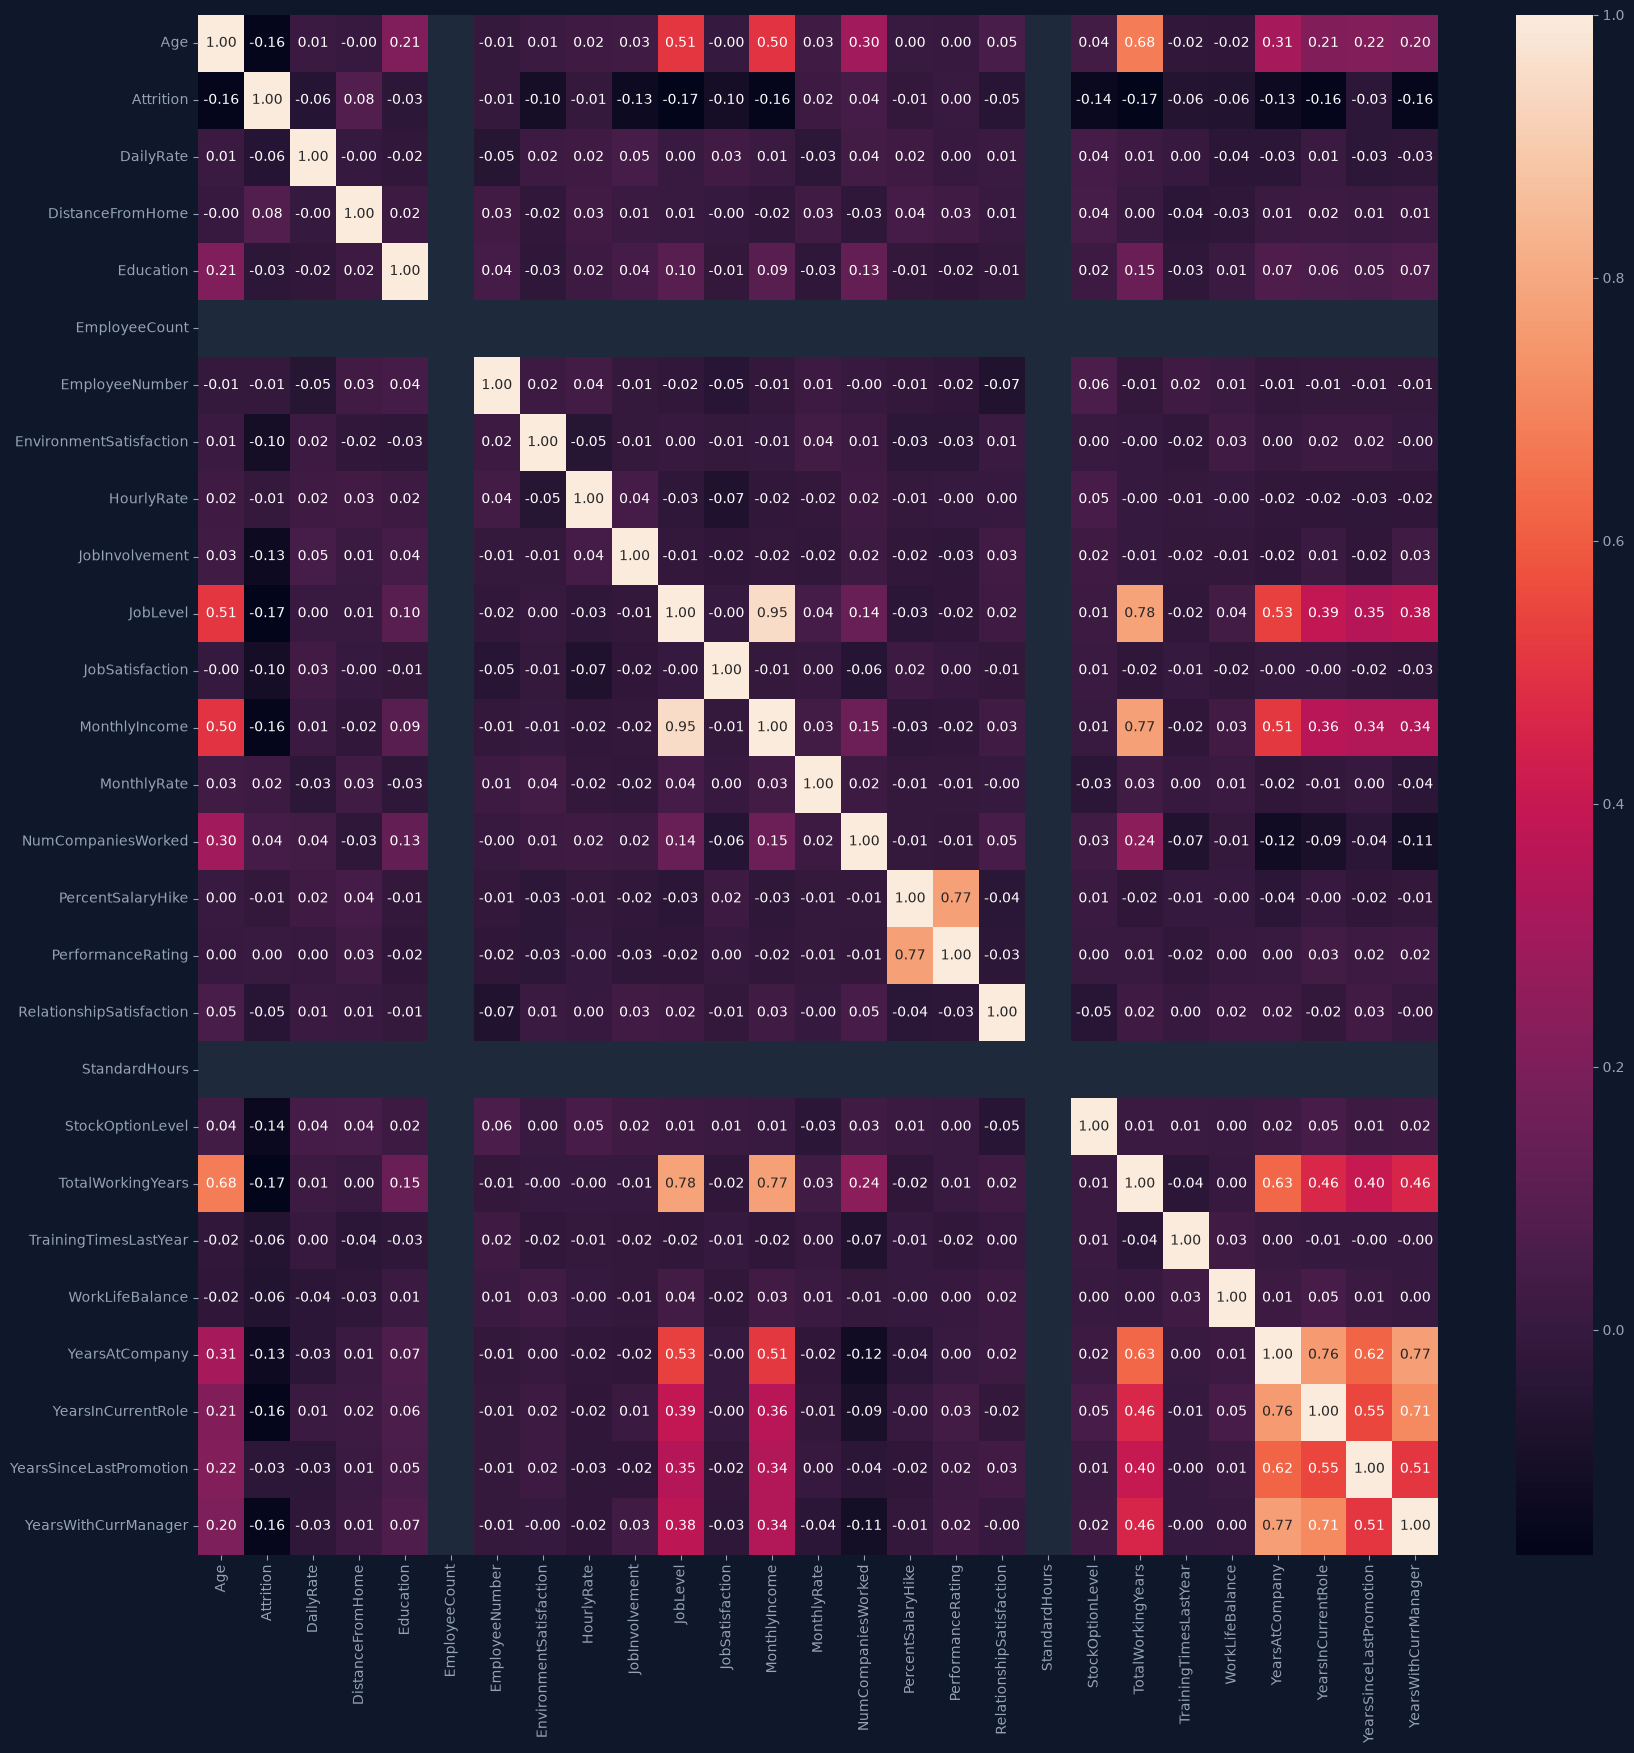

In [18]:
f, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(correlacao_exploratoria.corr(numeric_only=True), annot=True, fmt='.2f', ax=ax)
plt.show()

In [42]:
pares = correlacao_exploratoria.corr(numeric_only=True).unstack()
pares

Age                   Age                        1.000000
                      Attrition                 -0.159205
                      DailyRate                  0.010661
                      DistanceFromHome          -0.001686
                      Education                  0.208034
                                                   ...   
YearsWithCurrManager  WorkLifeBalance            0.002759
                      YearsAtCompany             0.769212
                      YearsInCurrentRole         0.714365
                      YearsSinceLastPromotion    0.510224
                      YearsWithCurrManager       1.000000
Length: 729, dtype: float64

In [43]:
alta_correlacao = pares[(pares > .6) & (pares < 1.0)]
alta_correlacao

Age                      TotalWorkingYears          0.680381
JobLevel                 MonthlyIncome              0.950300
                         TotalWorkingYears          0.782208
MonthlyIncome            JobLevel                   0.950300
                         TotalWorkingYears          0.772893
PercentSalaryHike        PerformanceRating          0.773550
PerformanceRating        PercentSalaryHike          0.773550
TotalWorkingYears        Age                        0.680381
                         JobLevel                   0.782208
                         MonthlyIncome              0.772893
                         YearsAtCompany             0.628133
YearsAtCompany           TotalWorkingYears          0.628133
                         YearsInCurrentRole         0.758754
                         YearsSinceLastPromotion    0.618409
                         YearsWithCurrManager       0.769212
YearsInCurrentRole       YearsAtCompany             0.758754
                        

### 3.4 Perfil comportamental por variáveis categóricas

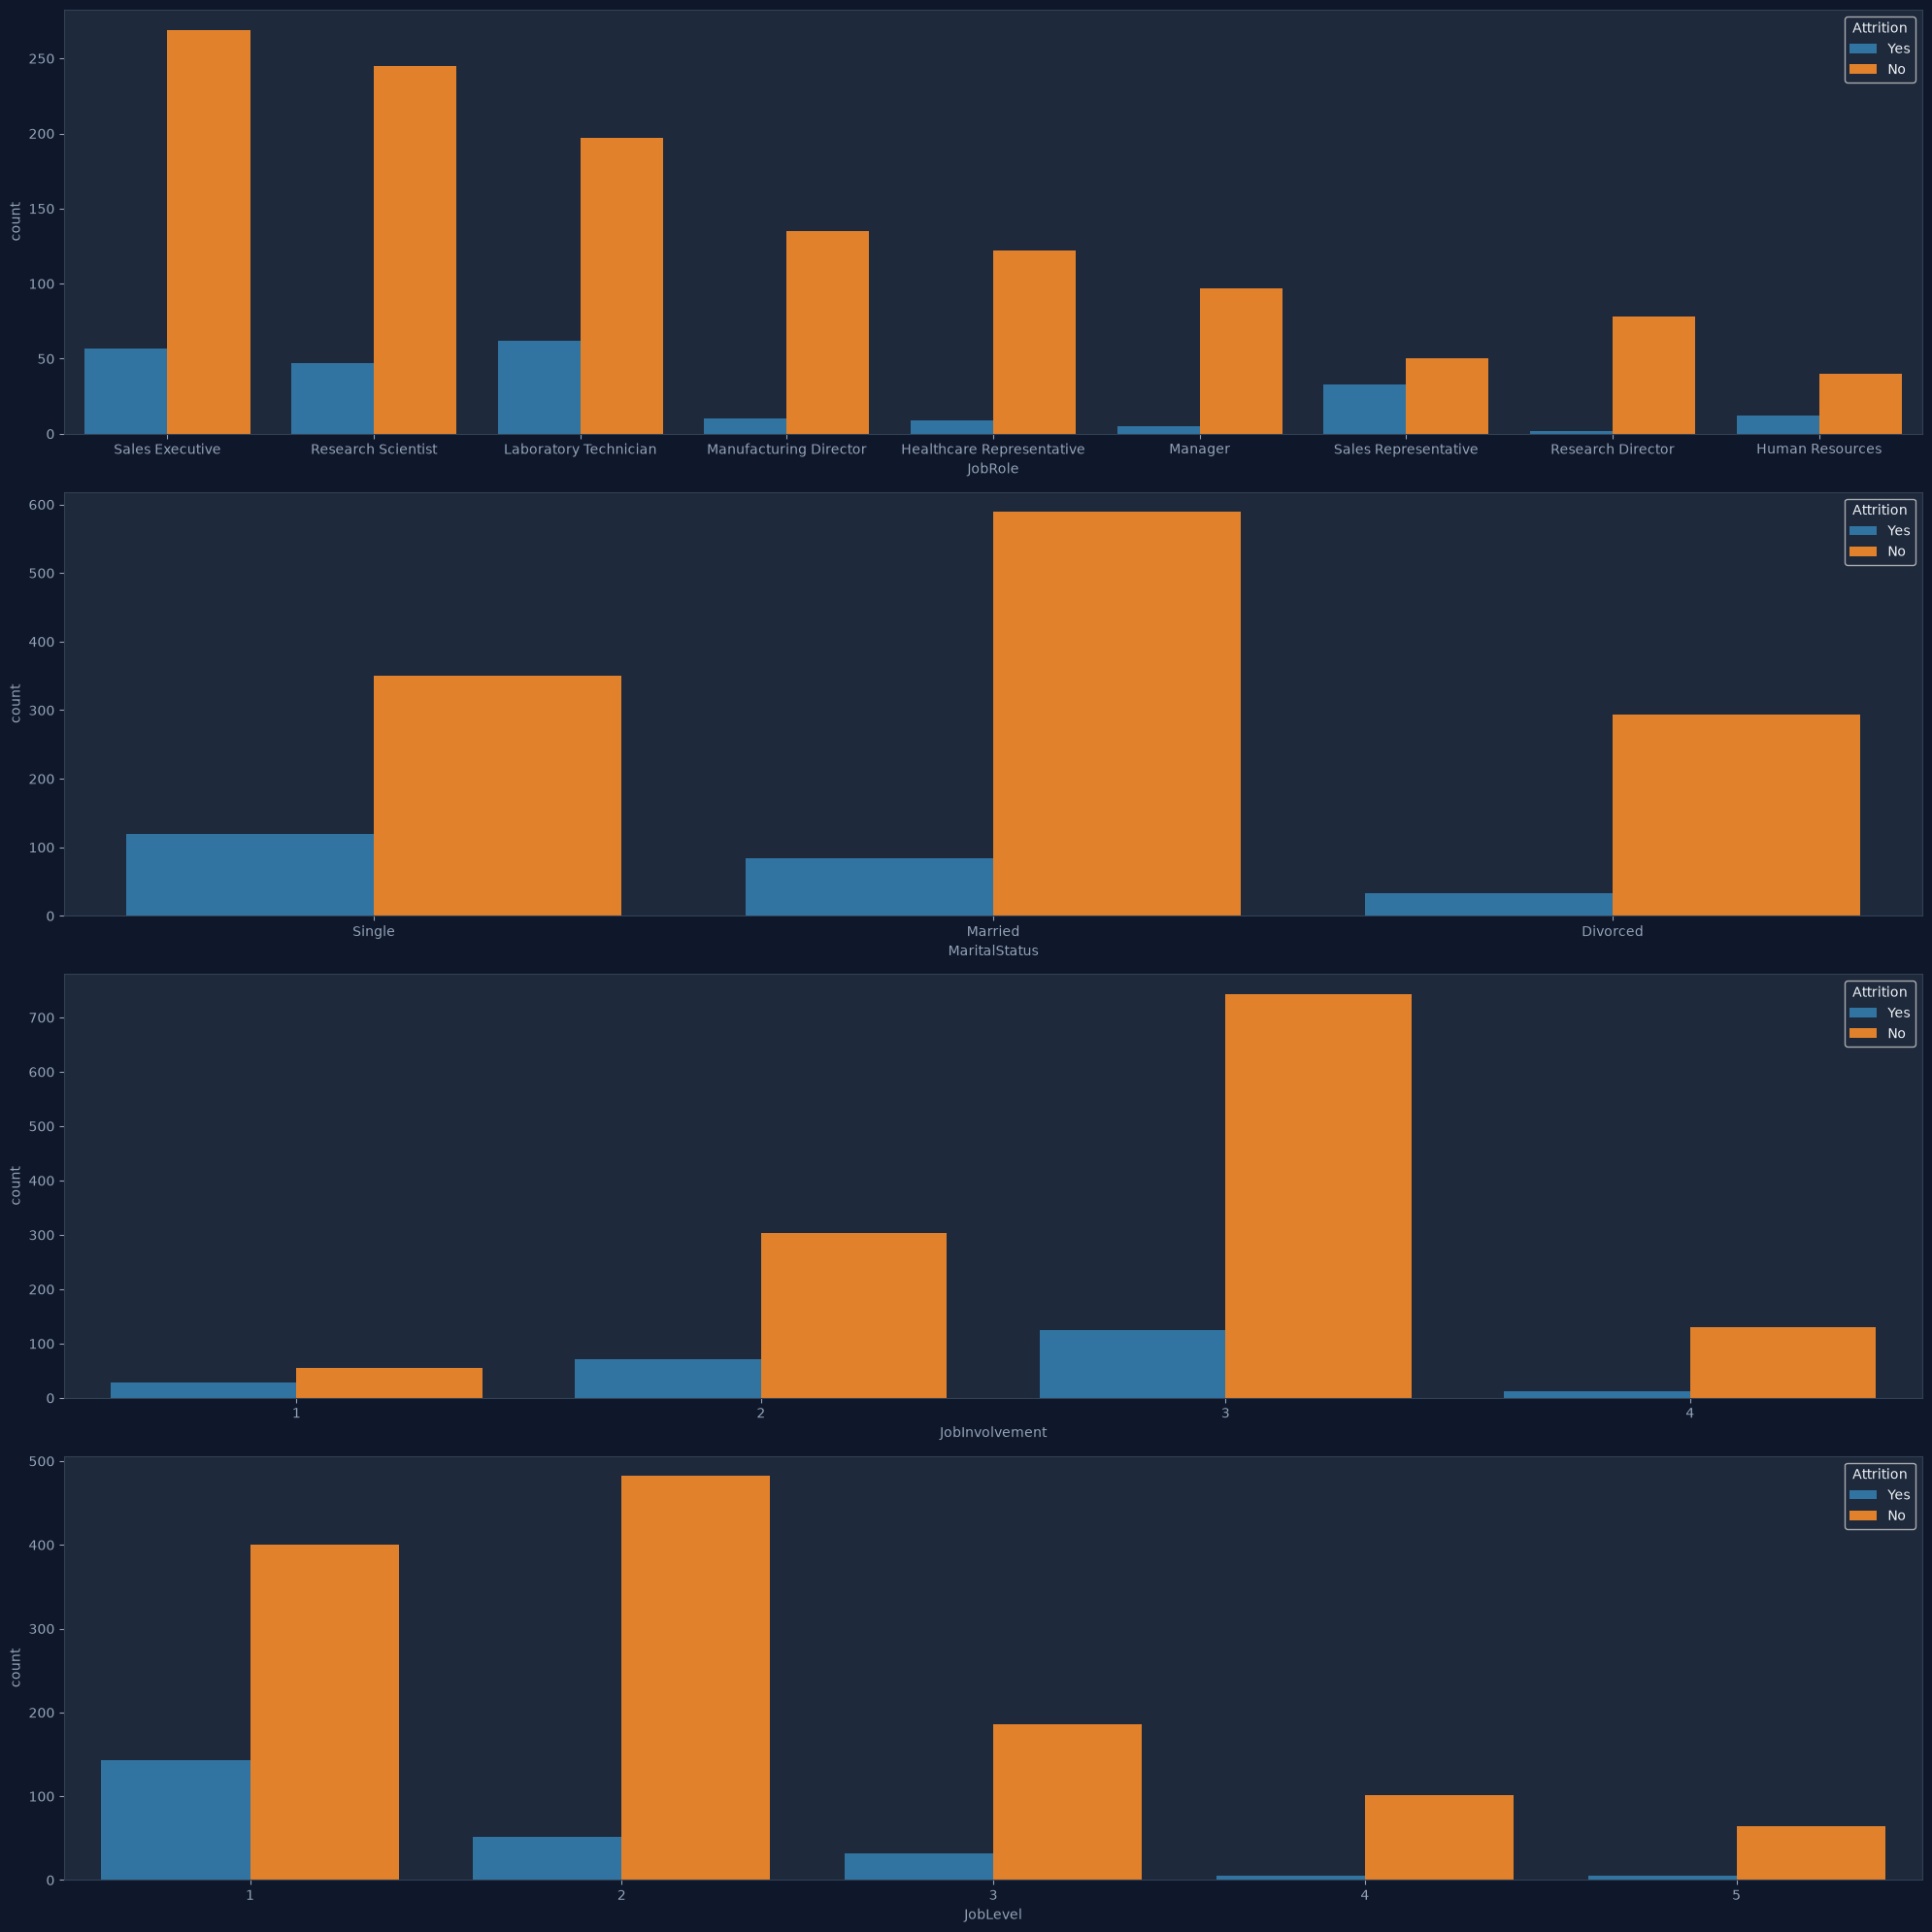

In [19]:
plt.figure(figsize=[20, 20])

plt.subplot(411)
sns.countplot(x='JobRole', hue='Attrition', data=employee_df)

plt.subplot(412)
sns.countplot(x='MaritalStatus', hue='Attrition', data=employee_df)

plt.subplot(413)
sns.countplot(x='JobInvolvement', hue='Attrition', data=employee_df)

plt.subplot(414)
sns.countplot(x='JobLevel', hue='Attrition', data=employee_df)

plt.tight_layout()
plt.show()

### 3.5 Distribuições comparativas entre quem saiu e quem ficou

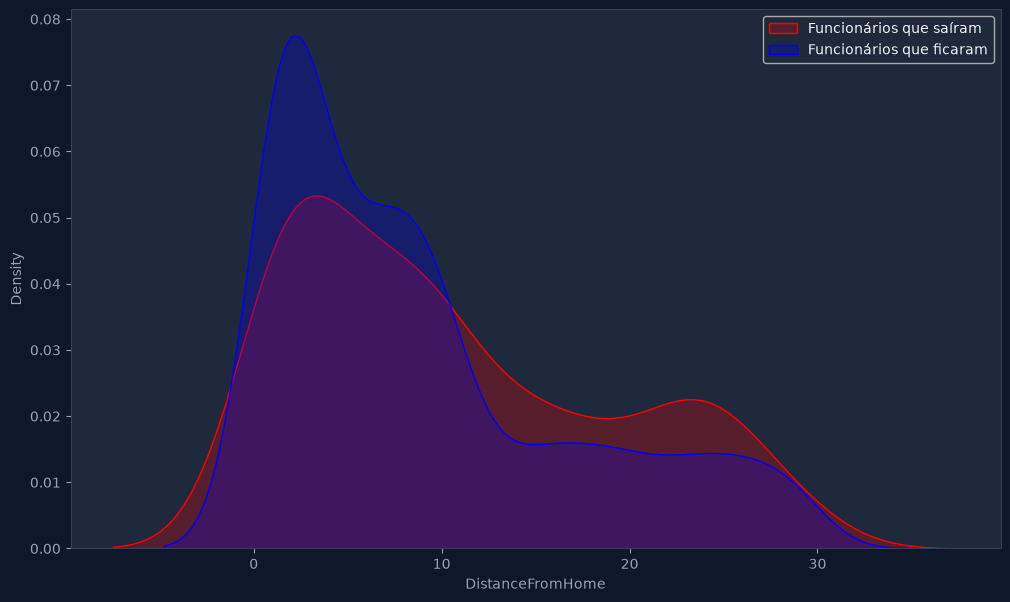

In [22]:
left_df = employee_df[employee_df['Attrition'] == 'Yes']
stayed_df = employee_df[employee_df['Attrition'] == 'No']

plt.figure(figsize=(12, 7))
sns.kdeplot(left_df['DistanceFromHome'], label='Funcionários que saíram', shade=True, color='r')
sns.kdeplot(stayed_df['DistanceFromHome'], label='Funcionários que ficaram', shade=True, color='b')
plt.legend()
plt.show()

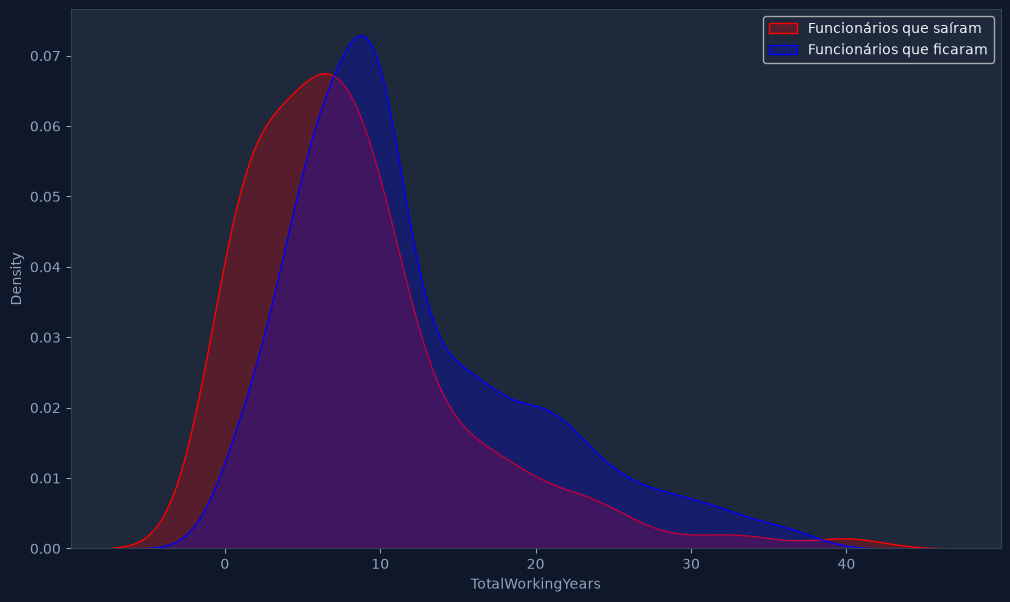

In [23]:
plt.figure(figsize=(12, 7))
sns.kdeplot(left_df['TotalWorkingYears'], label='Funcionários que saíram', shade=True, color='r')
sns.kdeplot(stayed_df['TotalWorkingYears'], label='Funcionários que ficaram', shade=True, color='b')
plt.legend()
plt.show()

### 3.6 Renda por gênero e por cargo

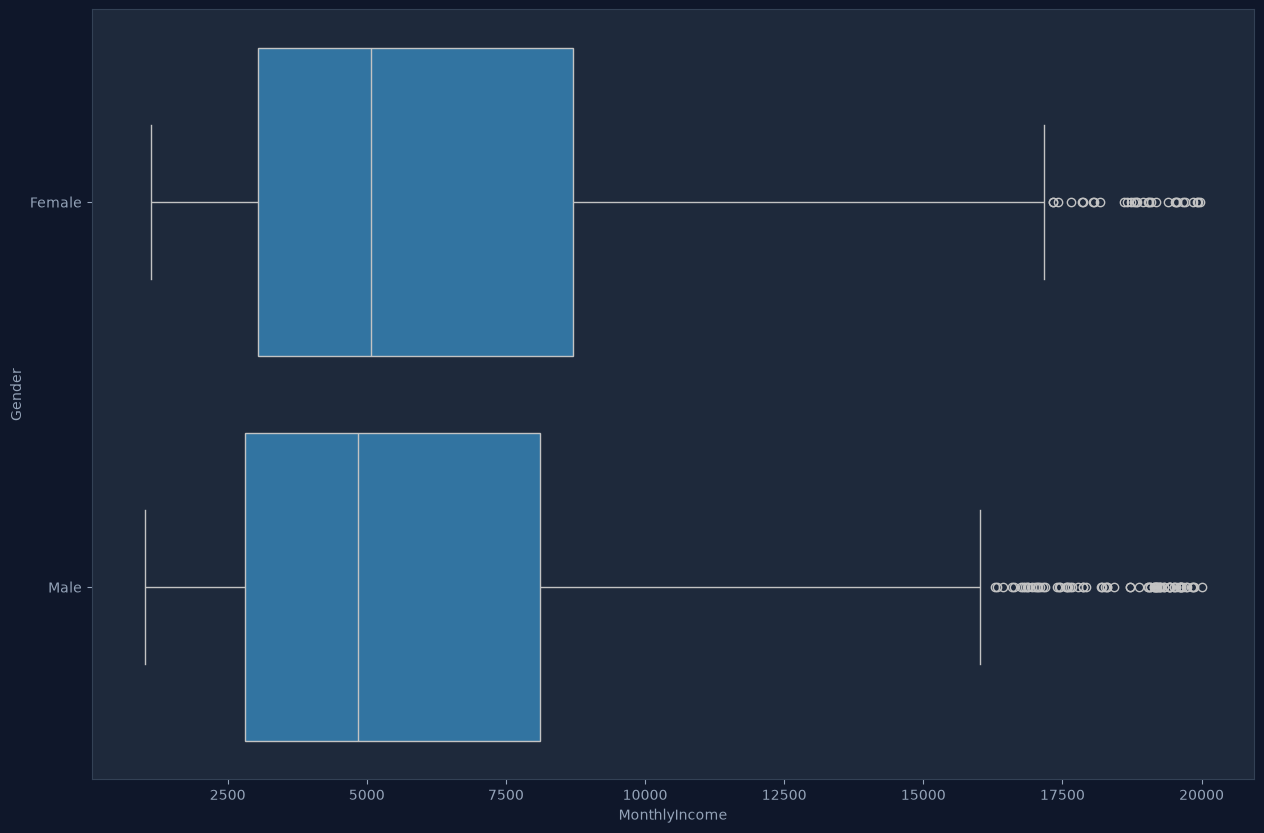

In [37]:
plt.figure(figsize=(15, 10))
sns.boxplot(x='MonthlyIncome', 
            y='Gender',
            data=employee_df,
            linecolor='#c3c3c3',
           )
plt.show()

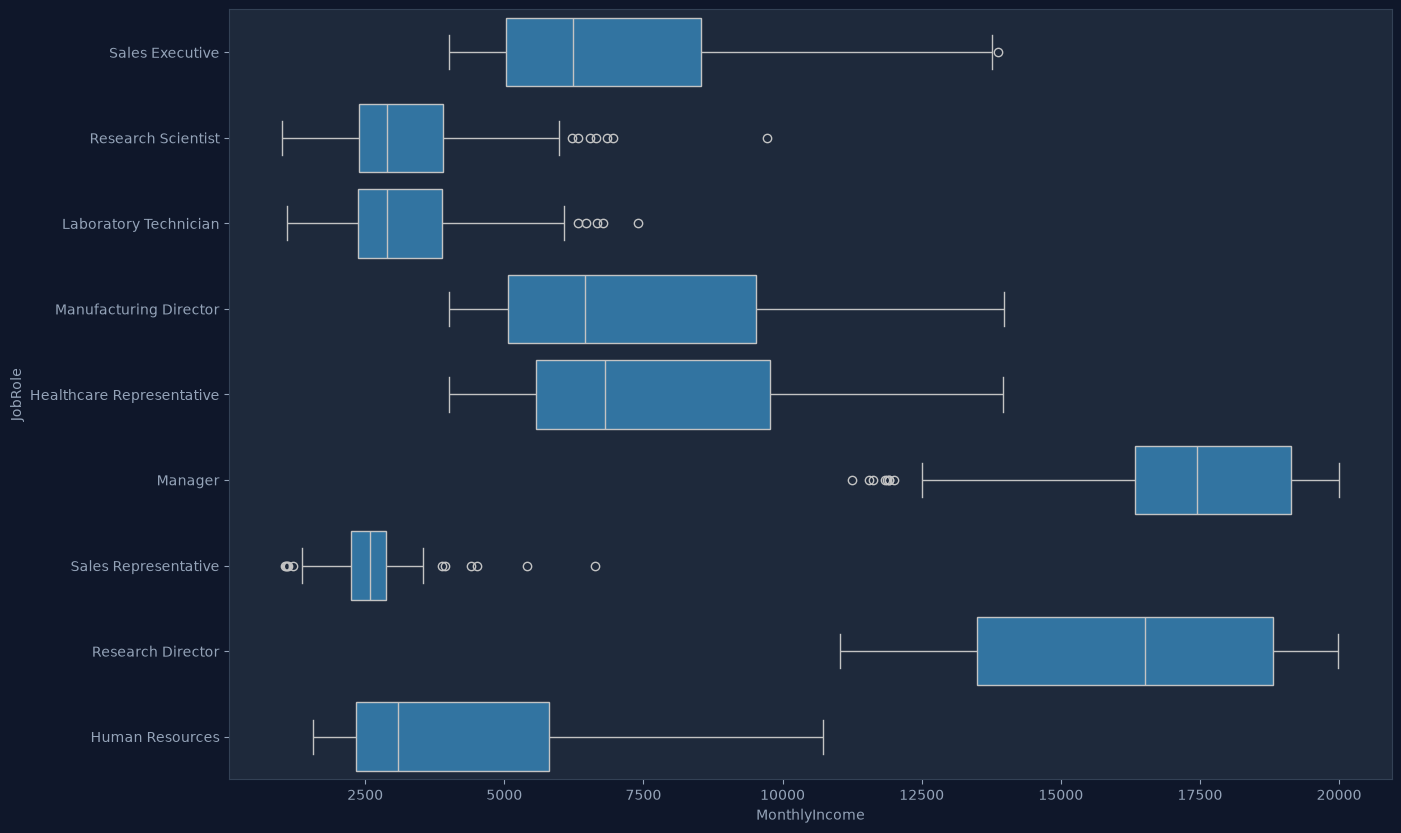

In [38]:
plt.figure(figsize=(15, 10))
sns.boxplot(x='MonthlyIncome', y='JobRole', data=employee_df, linecolor='#c3c3c3',)
plt.show()

### 3.7 Resumo da análise exploratória

## 4. Tratamento e Limpeza dos Dados

### 4.1 Remoção de colunas constantes e identificadoras

In [19]:
antes = employee_df.shape[1]

employee_df.drop(
    ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'],
    axis=1,
    inplace=True
)

print(f"Colunas removidas: {antes - employee_df.shape[1]}")
print(f"Colunas restantes: {employee_df.shape[1]}")

Colunas removidas: 4
Colunas restantes: 31


### 4.2 Codificação das variáveis binárias

Converto as variáveis binárias para valores numéricos, tornando-as compatíveis com os algoritmos de Machine Learning. Como possuem apenas duas categorias, não há necessidade de aplicar One-Hot Encoding.

In [20]:
employee_df['Attrition'] = employee_df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

employee_df['OverTime'] = employee_df['OverTime'].map({
    'Yes': 1,
    'No': 0
})

employee_df[['Attrition', 'OverTime']].head()

,Attrition,OverTime
0,1,1
1,0,0
2,1,1
3,0,1
4,0,0


### 4.3 Resumo do impacto acumulado

> Os atributos constantes foram removidos com sucesso nesta etapa e logo a seguir foi feito a codificação binária das categóricas simples.

## 5. Preparação para Modelagem

Nesta etapa preparo os dados para treinamento dos modelos. Diferentemente da limpeza realizada na seção anterior, as transformações aqui são ajustadas exclusivamente com o conjunto de treinamento, evitando vazamento de informação (*data leakage*) para o conjunto de teste.

### 5.1 Separação entre variáveis preditoras e variável alvo

Separo a variável alvo (`y`) das variáveis preditoras (`X`), garantindo que a resposta não participe das etapas de pré-processamento.

In [21]:
X = employee_df.drop(columns='Attrition')
y = employee_df['Attrition']

In [7]:
X

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,3,1,0,8,0,1,6,4,0,5
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,...,4,4,1,10,3,3,10,7,1,7
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,...,3,2,0,7,3,3,0,0,0,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,...,3,3,0,8,3,3,8,7,3,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,41,...,3,3,1,17,3,3,5,2,0,3
1466,39,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,42,...,3,1,1,9,5,3,7,7,1,7
1467,27,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,87,...,4,2,1,6,0,3,6,2,0,3
1468,49,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,63,...,3,4,0,17,3,2,9,6,0,8


In [8]:
y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

### 5.2 Separação entre treino e teste

Realizo a divisão dos dados antes de qualquer transformação. Dessa forma, todas as etapas de pré-processamento aprendem apenas com os dados de treinamento.

Utilizo `stratify=y` para preservar a proporção entre as classes e `random_state` para garantir a reprodutibilidade dos experimentos.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.25,
                                                    random_state=RANDOM_STATE,
                                                    stratify=y)

X_train.shape, X_test.shape

((1102, 30), (368, 30))

### 5.3 Identificação das variáveis categóricas e numéricas

Identifico automaticamente quais atributos são categóricos e quais são numéricos utilizando `select_dtypes()`. Essa abordagem reduz dependências de listas escritas manualmente e torna o código mais reutilizável para outros conjuntos de dados.

In [23]:
colunas_categoricas = X_train.select_dtypes(
    include='object'
).columns

colunas_numericas = X_train.select_dtypes(
    include='number'
).columns

In [24]:
colunas_categoricas

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus'],
      dtype='str')

In [25]:
colunas_numericas

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

### 5.4 Pré-processamento com ColumnTransformer

Centralizo todas as transformações em um único objeto utilizando `ColumnTransformer`. As variáveis categóricas são codificadas com `OneHotEncoder`, enquanto as variáveis numéricas são normalizadas com `MinMaxScaler`.

O parâmetro `drop='first'` evita a armadilha da variável dummy, enquanto `handle_unknown='ignore'` garante que categorias não observadas durante o treinamento não provoquem erros durante a inferência.

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categoricas',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            colunas_categoricas
        ),
        (
            'numericas',
            MinMaxScaler(),
            colunas_numericas
        )
    ]
)

### 5.5 Aplicação do pré-processamento

Ajusto (`fit`) o pré-processador apenas utilizando o conjunto de treinamento. Em seguida aplico (`transform`) exatamente a mesma transformação ao conjunto de teste.

Esse procedimento impede vazamento de informação e garante uma avaliação mais confiável do desempenho dos modelos.

In [29]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

### 5.6 Verificação da distribuição das classes

Confirmo que a divisão estratificada preservou a proporção entre funcionários que permaneceram e que deixaram a empresa nos conjuntos de treinamento e teste.

In [30]:
print('Proporção de Attrition no treino:')
print(y_train.value_counts(normalize=True))

print('\nProporção de Attrition no teste:')
print(y_test.value_counts(normalize=True))

Proporção de Attrition no treino:
Attrition
0    0.838475
1    0.161525
Name: proportion, dtype: float64

Proporção de Attrition no teste:
Attrition
0    0.839674
1    0.160326
Name: proportion, dtype: float64
